# ASVspoof5 Train-Only Gender Logistic Baselines (A01-A08)

Reads prebuilt manifests from `prepare_asvspoof5_train_gender_50spk_2000perclass_A01A08.ipynb`,
extracts embeddings from train tar shards, and trains 4 binary logistic models per gender:
- bonafide vs A01
- bonafide vs A02
- bonafide vs A03
- bonafide vs A04
- bonafide vs A05
- bonafide vs A06
- bonafide vs A07
- bonafide vs A08

Train/test split is taken from manifest (`speaker-disjoint` by construction).


In [2]:
import io
import json
import pickle
import tarfile
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torchaudio
from tqdm import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report


In [3]:
# ===== Config =====
PROJECT_ROOT = Path('/home/SpeakerRec/BioVoice')

PLAN_BASE = (
    PROJECT_ROOT
    / "data"
    / "datasets"
    / "ASVspoof5_tars"
    / "ASVspoof5_protocols"
    / "gender_50spk_2000perclass_A01A08_outputs"
)
MANIFESTS = {
    'male': PLAN_BASE / 'male' / 'selected_utterances_plan.csv',
    'female': PLAN_BASE / 'female' / 'selected_utterances_plan.csv',
}

TRAIN_TAR_DIR = PROJECT_ROOT / 'data' / 'datasets' / 'ASVspoof5_tars' / 'ASVspoof5_audio_train_tars'
OUT_BASE = PROJECT_ROOT / 'data' / 'models' / 'asvspoof5_train_gender_50spk_2000perclass_A01A08'
OUT_BASE.mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
FORCE_RECOMPUTE_EMBEDDINGS = False
SAVE_PREDICTIONS = True

TARGET_SYSTEMS = ['A01','A02','A03','A04','A05','A06','A07','A08']

print('DEVICE =', DEVICE)
print('PLAN_BASE =', PLAN_BASE)
print('TRAIN_TAR_DIR =', TRAIN_TAR_DIR, '| exists =', TRAIN_TAR_DIR.exists())
for g,m in MANIFESTS.items():
    print(f'{g} manifest = {m} | exists =', m.exists())
print('OUT_BASE =', OUT_BASE)

DEVICE = cuda
PLAN_BASE = /home/SpeakerRec/BioVoice/data/datasets/ASVspoof5_tars/ASVspoof5_protocols/gender_50spk_2000perclass_A01A08_outputs
TRAIN_TAR_DIR = /home/SpeakerRec/BioVoice/data/datasets/ASVspoof5_tars/ASVspoof5_audio_train_tars | exists = True
male manifest = /home/SpeakerRec/BioVoice/data/datasets/ASVspoof5_tars/ASVspoof5_protocols/gender_50spk_2000perclass_A01A08_outputs/male/selected_utterances_plan.csv | exists = True
female manifest = /home/SpeakerRec/BioVoice/data/datasets/ASVspoof5_tars/ASVspoof5_protocols/gender_50spk_2000perclass_A01A08_outputs/female/selected_utterances_plan.csv | exists = True
OUT_BASE = /home/SpeakerRec/BioVoice/data/models/asvspoof5_train_gender_50spk_2000perclass_A01A08


In [3]:
# ===== Model =====
redim_model = (
    torch.hub.load(
        'IDRnD/ReDimNet',
        'ReDimNet',
        model_name='b6',
        train_type='ptn',
        dataset='vox2',
    )
    .to(DEVICE)
    .eval()
)
print('Loaded ReDimNet on', DEVICE)


Using cache found in /home/SpeakerRec/.cache/torch/hub/IDRnD_ReDimNet_master


Loaded ReDimNet on cuda


In [4]:
def embed_waveform(wav: torch.Tensor, sr: int) -> np.ndarray:
    if sr != 16000:
        wav = torchaudio.functional.resample(wav, sr, 16000)
    if wav.ndim == 1:
        wav = wav.unsqueeze(0)
    if wav.shape[0] > 1:
        wav = wav[:1, :]
    wav = wav.to(DEVICE)
    with torch.no_grad():
        emb = redim_model(wav)
    return emb.squeeze(0).detach().cpu().numpy().astype(np.float32)


def embed_member_from_tar(tf: tarfile.TarFile, member: tarfile.TarInfo) -> np.ndarray:
    fobj = tf.extractfile(member)
    if fobj is None:
        raise RuntimeError(f'Cannot extract member: {member.name}')
    raw = fobj.read()
    try:
        wav, sr = torchaudio.load(io.BytesIO(raw))
    except Exception:
        # Fallback via temporary file when backend cannot load BytesIO
        import tempfile
        suffix = Path(member.name).suffix or '.flac'
        with tempfile.NamedTemporaryFile(suffix=suffix, delete=True) as tmp:
            tmp.write(raw)
            tmp.flush()
            wav, sr = torchaudio.load(tmp.name)
    return embed_waveform(wav, sr)


def extract_embeddings_for_manifest(manifest_df: pd.DataFrame, cache_npz: Path, force_recompute: bool=False):
    # return embeddings in same row order as manifest_df
    if cache_npz.exists() and not force_recompute:
        payload = np.load(cache_npz, allow_pickle=True)
        X = payload['X']
        utt_ids = payload['utt_ids'].astype(str)
        lut = pd.DataFrame({'utt_id': utt_ids, '_idx': np.arange(len(utt_ids))})
        m = manifest_df[['utt_id']].merge(lut, on='utt_id', how='left', validate='one_to_one')
        if m['_idx'].isna().any():
            miss = m.loc[m['_idx'].isna(), 'utt_id'].tolist()[:10]
            raise RuntimeError(f'Embedding cache missing utt_ids, examples={miss}')
        return X[m['_idx'].astype(int).to_numpy()]

    tars = sorted(TRAIN_TAR_DIR.glob('flac_T_*.tar'))
    assert len(tars) > 0, f'No train tar files in {TRAIN_TAR_DIR}'

    need = set(manifest_df['utt_id'].astype(str).tolist())

    emb_map = {}
    found = set()

    for tar_path in tars:
        print('Reading', tar_path.name)
        with tarfile.open(tar_path, 'r') as tf:
            for m in tf:
                if not m.isfile():
                    continue
                utt = Path(Path(m.name).name).stem
                if utt not in need or utt in found:
                    continue
                emb_map[utt] = embed_member_from_tar(tf, m)
                found.add(utt)
        print('Found so far:', len(found), '/', len(need))

    missing = sorted(list(need - found))
    if missing:
        raise RuntimeError(f'Missing {len(missing)} utt_ids in train tars. examples={missing[:10]}')

    ids = manifest_df['utt_id'].astype(str).tolist()
    X = np.stack([emb_map[u] for u in ids]).astype(np.float32)
    np.savez_compressed(cache_npz, X=X, utt_ids=np.array(ids, dtype=object))
    return X


In [5]:
def compute_metrics(y_true, p_spoof, thr=0.5):
    y_hat = (p_spoof >= thr).astype(int)
    cm = confusion_matrix(y_true, y_hat).tolist()
    return {
        'accuracy': float(accuracy_score(y_true, y_hat)),
        'auc': float(roc_auc_score(y_true, p_spoof)) if len(np.unique(y_true)) == 2 else None,
        'confusion_matrix': cm,
        'classification_report': classification_report(y_true, y_hat, output_dict=True, zero_division=0),
    }


all_summary_rows = []

for gender_name, manifest_path in MANIFESTS.items():
    print(f"\n===== {gender_name.upper()} =====")
    assert manifest_path.exists(), f'Missing manifest: {manifest_path}'
    g_dir = OUT_BASE / gender_name
    g_dir.mkdir(parents=True, exist_ok=True)

    df = pd.read_csv(manifest_path)
    req_cols = {'split','speaker_id','utt_id','gender','label','system_id','sample_class','target_class'}
    missing = req_cols - set(df.columns)
    if missing:
        raise ValueError(f'{gender_name} manifest missing cols: {sorted(missing)}')

    # Global embedding cache for this gender manifest
    cache_npz = g_dir / 'embeddings_all_selected.npz'
    X_all = extract_embeddings_for_manifest(df[['utt_id']], cache_npz, force_recompute=FORCE_RECOMPUTE_EMBEDDINGS)

    # Save a quick sanity snapshot
    (g_dir / 'manifest_snapshot.csv').write_text(df.head(200).to_csv(index=False), encoding='utf-8')

    for sys_id in TARGET_SYSTEMS:
        print(f'-- Task bonafide vs {sys_id}')
        task_df = df[df['target_class'].isin(['bonafide', sys_id])].copy().reset_index(drop=True)
        assert not task_df.empty, f'Empty task data for {gender_name}/{sys_id}'

        idx_map = pd.DataFrame({'utt_id': df['utt_id'].astype(str), '_idx': np.arange(len(df))})
        pick = task_df[['utt_id']].astype(str).merge(idx_map, on='utt_id', how='left', validate='one_to_one')
        if pick['_idx'].isna().any():
            raise RuntimeError(f'Index mapping failed for {gender_name}/{sys_id}')

        X = X_all[pick['_idx'].astype(int).to_numpy()]
        y = np.where(task_df['target_class'].eq('bonafide'), 0, 1).astype(int)

        is_train = task_df['split'].eq('train').to_numpy()
        is_test = task_df['split'].eq('test').to_numpy()

        X_tr, y_tr = X[is_train], y[is_train]
        X_te, y_te = X[is_test], y[is_test]

        assert len(X_tr) > 0 and len(X_te) > 0, f'Empty split for {gender_name}/{sys_id}'
        assert set(np.unique(y_tr)) == {0,1}, f'Train class imbalance issue {gender_name}/{sys_id}'
        assert set(np.unique(y_te)) == {0,1}, f'Test class imbalance issue {gender_name}/{sys_id}'

        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)

        clf = LogisticRegression(max_iter=2000, C=1.0, class_weight=None, random_state=42, n_jobs=-1)
        clf.fit(X_tr_s, y_tr)

        p_tr = clf.predict_proba(X_tr_s)[:, 1]
        p_te = clf.predict_proba(X_te_s)[:, 1]

        m_tr = compute_metrics(y_tr, p_tr, thr=0.5)
        m_te = compute_metrics(y_te, p_te, thr=0.5)

        task_dir = g_dir / sys_id
        task_dir.mkdir(parents=True, exist_ok=True)
        with open(task_dir / 'scaler.pkl', 'wb') as f:
            pickle.dump(scaler, f)
        with open(task_dir / 'logistic_regression.pkl', 'wb') as f:
            pickle.dump(clf, f)

        run_summary = {
            'gender_set': gender_name,
            'task': f'bonafide_vs_{sys_id}',
            'train_rows': int(len(task_df[task_df['split']=='train'])),
            'test_rows': int(len(task_df[task_df['split']=='test'])),
            'metrics_train_thr_0_5': m_tr,
            'metrics_test_thr_0_5': m_te,
        }
        (task_dir / 'run_summary.json').write_text(json.dumps(run_summary, indent=2), encoding='utf-8')

        if SAVE_PREDICTIONS:
            pred_tr = task_df.loc[is_train, ['split','speaker_id','utt_id','gender','target_class']].copy().reset_index(drop=True)
            pred_tr['label_id'] = y_tr
            pred_tr['prob_spoof'] = p_tr
            pred_tr['pred_label_id_thr_0_5'] = (p_tr >= 0.5).astype(int)

            pred_te = task_df.loc[is_test, ['split','speaker_id','utt_id','gender','target_class']].copy().reset_index(drop=True)
            pred_te['label_id'] = y_te
            pred_te['prob_spoof'] = p_te
            pred_te['pred_label_id_thr_0_5'] = (p_te >= 0.5).astype(int)

            pd.concat([pred_tr, pred_te], ignore_index=True).to_csv(task_dir / f'predictions_bonafide_vs_{sys_id}.csv', index=False)

        all_summary_rows.append({
            'gender_set': gender_name,
            'task_system_id': sys_id,
            'train_n': int(len(y_tr)),
            'test_n': int(len(y_te)),
            'train_acc': m_tr['accuracy'],
            'train_auc': m_tr['auc'],
            'test_acc': m_te['accuracy'],
            'test_auc': m_te['auc'],
            'test_cm_00': int(m_te['confusion_matrix'][0][0]),
            'test_cm_01': int(m_te['confusion_matrix'][0][1]),
            'test_cm_10': int(m_te['confusion_matrix'][1][0]),
            'test_cm_11': int(m_te['confusion_matrix'][1][1]),
        })

        del X, y, X_tr, y_tr, X_te, y_te, X_tr_s, X_te_s
        gc.collect()

summary_df = pd.DataFrame(all_summary_rows).sort_values(['gender_set','task_system_id']).reset_index(drop=True)
summary_df.to_csv(OUT_BASE / 'metrics_summary.csv', index=False)
print('Saved metrics summary ->', OUT_BASE / 'metrics_summary.csv')
display(summary_df)



===== MALE =====
Reading flac_T_aa.tar
Found so far: 3603 / 18000
Reading flac_T_ab.tar
Found so far: 7216 / 18000
Reading flac_T_ac.tar
Found so far: 10840 / 18000
Reading flac_T_ad.tar
Found so far: 14376 / 18000
Reading flac_T_ae.tar
Found so far: 18000 / 18000
-- Task bonafide vs A01
-- Task bonafide vs A02
-- Task bonafide vs A03
-- Task bonafide vs A04
-- Task bonafide vs A05
-- Task bonafide vs A06
-- Task bonafide vs A07
-- Task bonafide vs A08

===== FEMALE =====
Reading flac_T_aa.tar
Found so far: 3622 / 18000
Reading flac_T_ab.tar
Found so far: 7274 / 18000
Reading flac_T_ac.tar
Found so far: 10899 / 18000
Reading flac_T_ad.tar
Found so far: 14476 / 18000
Reading flac_T_ae.tar
Found so far: 18000 / 18000
-- Task bonafide vs A01
-- Task bonafide vs A02
-- Task bonafide vs A03
-- Task bonafide vs A04
-- Task bonafide vs A05
-- Task bonafide vs A06
-- Task bonafide vs A07
-- Task bonafide vs A08
Saved metrics summary -> /home/SpeakerRec/BioVoice/data/models/asvspoof5_train_gen

,gender_set,task_system_id,train_n,test_n,train_acc,train_auc,test_acc,test_auc,test_cm_00,test_cm_01,test_cm_10,test_cm_11
0,female,A01,2800,1200,1.0,1.0,0.992500,0.999850,591,9,0,600
1,female,A02,2800,1200,1.0,1.0,0.995000,0.999972,594,6,0,600
2,female,A03,2800,1200,1.0,1.0,0.989167,0.999925,587,13,0,600
3,female,A04,2800,1200,1.0,1.0,0.990833,0.999994,589,11,0,600
4,female,A05,2800,1200,1.0,1.0,0.995000,0.999933,594,6,0,600
5,female,A06,2800,1200,1.0,1.0,0.978333,0.998864,580,20,6,594
6,female,A07,2800,1200,1.0,1.0,1.000000,1.000000,600,0,0,600
7,female,A08,2800,1200,1.0,1.0,0.917500,0.984503,520,80,19,581
8,male,A01,2800,1200,1.0,1.0,0.976667,0.999622,572,28,0,600
9,male,A02,2800,1200,1.0,1.0,0.994167,1.000000,593,7,0,600


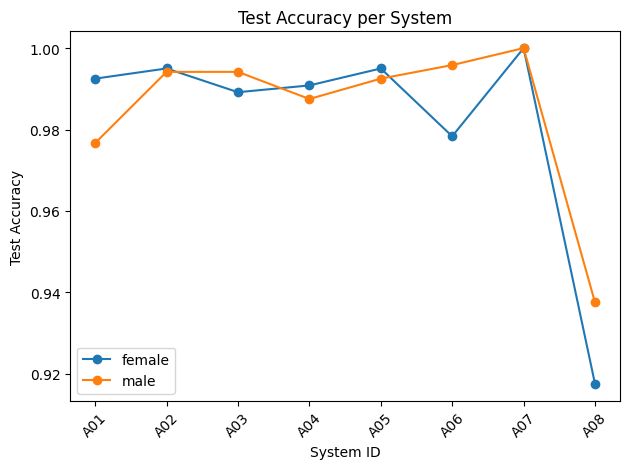

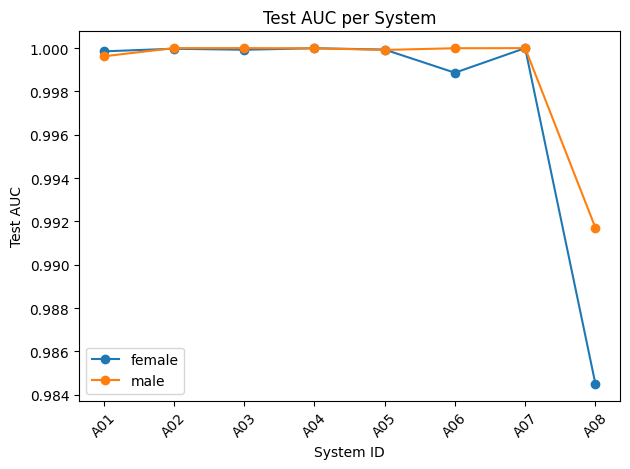

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# load if needed (optional)
summary_df = pd.read_csv(OUT_BASE / "metrics_summary.csv")

# --- Accuracy plot ---
plt.figure()
for gender in summary_df["gender_set"].unique():
    sub = summary_df[summary_df["gender_set"] == gender]
    plt.plot(sub["task_system_id"], sub["test_acc"], marker="o", label=gender)

plt.xlabel("System ID")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy per System")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# --- AUC plot ---
plt.figure()
for gender in summary_df["gender_set"].unique():
    sub = summary_df[summary_df["gender_set"] == gender]
    plt.plot(sub["task_system_id"], sub["test_auc"], marker="o", label=gender)

plt.xlabel("System ID")
plt.ylabel("Test AUC")
plt.title("Test AUC per System")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()